In [1]:
import sys
print("Python %s" % sys.version)
from IPython.display import Image
from math import *
from copy import copy
import random
from collections import deque

Python 3.14.4 (main, Apr  8 2026, 04:02:31) [GCC 15.2.0]


In [2]:
import numpy as np
print("NumPy %s" % np.__version__)

NumPy 2.4.3


In [3]:
import torch
print("PyTorch %s" % torch.__version__)
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

PyTorch 2.11.0+xpu


In [4]:
import matplotlib
print("matplotlib %s" % matplotlib.__version__)
matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt

matplotlib 3.10.9


In [5]:
%%bash

pip install progressbar

In [6]:
import progressbar as pb

In [7]:
from ConnectN import ConnectN

In [8]:
import MCTS

In [9]:
# check which device is being used. 
# I recommend disabling gpu until you've made sure that the code runs
device = MCTS.device
print("using device: ",device)

using device:  xpu


In [10]:
from Play import Play

# Setup a game

In [11]:
game_setting = {'size':(3,3), 'N':3}
game = ConnectN(**game_setting)

In [12]:
game.move((0,1))
print(game.state)
print(game.player)
print(game.score)

[[0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
-1
None


In [13]:
# player -1 move
game.move((0,0))
# player +1 move
game.move((1,1))
# player -1 move
game.move((1,0))
# player +1 move
game.move((2,1))

print(game.state)
print(game.player)
print(game.score)

[[-1.  1.  0.]
 [-1.  1.  0.]
 [ 0.  1.  0.]]
1
1


# Play a game interactively

In [14]:
gameplay=Play(ConnectN(**game_setting), 
              player1=None, 
              player2=None)

# Initialize an AI to play the game
We need to define a policy for tic-tac-toe, that takes the game state as input, and outputs a policy and a critic

## Tentative Exercise:
Code up your own policy for training

In [14]:
class Policy(nn.Module):

    def __init__(self):
        super(Policy, self).__init__()

        # solution
        self.conv = nn.Conv2d(1, 16, kernel_size=2, stride=1, bias=False)
        self.size = 2*2*16
        self.fc = nn.Linear(self.size,32)

        # layers for the policy
        self.fc_action1 = nn.Linear(32, 16)
        self.fc_action2 = nn.Linear(16, 9)
        
        # layers for the critic
        self.fc_value1 = nn.Linear(32, 8)
        self.fc_value2 = nn.Linear(8, 1)
        self.tanh_value = nn.Tanh()
        
    def forward(self, x):
        # solution
        y = F.relu(self.conv(x))
        y = y.reshape(-1, self.size)
        y = F.relu(self.fc(y))
        
        
        # the action head
        a = F.relu(self.fc_action1(y))
        a = self.fc_action2(a)
        # availability of moves
        avail = (torch.abs(x.squeeze())!=1).type(torch.FloatTensor).to(device)
        avail = avail.reshape(-1, 9)
        
        # locations where actions are not possible, we set the prob to zero
        maxa = torch.max(a)
        # subtract off max for numerical stability (avoids blowing up at infinity)
        exp = avail*torch.exp(a-maxa)
        prob = exp/torch.sum(exp)
        
        
        # the value head
        value = F.relu(self.fc_value1(y))
        value = self.tanh_value(self.fc_value2(value))
        return prob.reshape(3,3), value


policy = Policy().to(device)

In [15]:
policy

Policy(
  (conv): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
  (fc): Linear(in_features=64, out_features=32, bias=True)
  (fc_action1): Linear(in_features=32, out_features=16, bias=True)
  (fc_action2): Linear(in_features=16, out_features=9, bias=True)
  (fc_value1): Linear(in_features=32, out_features=8, bias=True)
  (fc_value2): Linear(in_features=8, out_features=1, bias=True)
  (tanh_value): Tanh()
)

In [16]:
policy.conv.weight.dtype

torch.float32

In [17]:
policy.conv.weight.device

device(type='xpu', index=0)

## Define a player that uses MCTS and the expert policy + critic to play a game

We've introduced a new parameter
$T$ = temperature

This tells us how to choose the next move based on the MCTS results

$$p_a = \frac{N_a^{\frac{1}{T}}}{\sum_a N_a^{\frac{1}{T}}}$$

$T \rightarrow 0$, we choose action with largest $N_a$. 

In [18]:
def Policy_Player_MCTS(game):
    mytree = MCTS.Node(copy(game))
    for _ in range(50):
        mytree.explore(policy)
   
    mytreenext, (v, nn_v, p, nn_p) = mytree.next(temperature=0.1)
        
    return mytreenext.game.last_move


def Random_Player(game):
    return random.choice(game.available_moves())

In [19]:
game = ConnectN(**game_setting)
print(game.state)
Policy_Player_MCTS(game)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


/home/eka/Workspace/DRLND/assignments/P4-Multi-Agent-Reinforcement-Learning/L3-Case-Study-AlphaZero/tic-tac-toe/MCTS.py:175: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  sibling.U = sibling.V + c*float(sibling.prob)* sqrt(mother.N)/(1+sibling.N)


(np.int64(1), np.int64(1))

# Play a game against the policy

In [21]:
gameplay=Play(ConnectN(**game_setting), 
              player1=None, 
              player2=Policy_Player_MCTS)

# Training Loop

In [20]:
# initialize our alphazero agent and optimizer
game=ConnectN(**game_setting)
policy = Policy().to(device)
optimizer = optim.Adam(policy.parameters(), lr=.01, weight_decay=1.e-4)

In [21]:
policy

Policy(
  (conv): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1), bias=False)
  (fc): Linear(in_features=64, out_features=32, bias=True)
  (fc_action1): Linear(in_features=32, out_features=16, bias=True)
  (fc_action2): Linear(in_features=16, out_features=9, bias=True)
  (fc_value1): Linear(in_features=32, out_features=8, bias=True)
  (fc_value2): Linear(in_features=8, out_features=1, bias=True)
  (tanh_value): Tanh()
)

In [22]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0.0001
)

## Tenative exercise:
code up the alphazero loss function, defined to be
$$L = \sum_t \left\{ (v^{(t)}_\theta - z)^2  - \sum_a p^{(t)}_a \log \pi_\theta(a|s_t) \right\} + \textrm{constant}$$ 
I added a constant term $\sum_t \sum_a p^{(t)}\log p^{(t)}$ so that when $v_\theta^{(t)} = z$ and $p^{(t)}_a = \pi_\theta(a|s_t)$, $L=0$, this way we can have some metric of progress.

In [23]:
# train our agent
episodes = 400
outcomes = []
losses = []

widget = ['training loop: ', pb.Percentage(), ' ', 
          pb.Bar(), ' ', pb.ETA() ]
timer = pb.ProgressBar(widgets=widget, maxval=episodes).start()

for e in range(episodes):

    mytree = MCTS.Node(ConnectN(**game_setting))
    vterm = []
    logterm = []
    
    while mytree.outcome is None:
        for _ in range(50):
            mytree.explore(policy)

        current_player = mytree.game.player
        mytree, (v, nn_v, p, nn_p) = mytree.next()        
        mytree.detach_mother()

        # solution
        # compute prob* log pi 
        loglist = torch.log(nn_p)*p
        
        # constant term to make sure if policy result = MCTS result, loss = 0
        constant = torch.where(p>0, p*torch.log(p),torch.tensor(0.))
        logterm.append((-torch.sum(loglist-constant).to("cpu")))
        
        vterm.append(nn_v*current_player)

        
    # we compute the "policy_loss" for computing gradient
    outcome = mytree.outcome
    outcomes.append(outcome)

    #solution
    loss = torch.sum( (torch.stack(vterm)-outcome)**2 + torch.stack(logterm) )
    optimizer.zero_grad()
    loss.backward()
    losses.append(float(loss))
    optimizer.step()
    
    if (e+1)%50==0:
        print("game: ",e+1, ", mean loss: {:3.2f}".format(np.mean(losses[-20:])),
              ", recent outcomes: ", outcomes[-10:])
    del loss
    
    timer.update(e+1)
    
    
timer.finish()

training loop:  12% |########                                                        | ETA:  0:00:44

game:  50 , mean loss: 7.13 , recent outcomes:  [0, 0, -1, 0, 1, -1, 1, 1, 0, 1]


training loop:  24% |###############                                                 | ETA:  0:00:36

game:  100 , mean loss: 6.18 , recent outcomes:  [1, 0, 0, 1, 0, 1, 0, 1, 0, 0]


training loop:  37% |########################                                        | ETA:  0:00:29

...

game:  300 , mean loss: 2.06 , recent outcomes:  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


training loop:  87% |########################################################        | ETA:  0:00:05

game:  350 , mean loss: 4.09 , recent outcomes:  [0, 1, 0, 0, 1, 0, -1, 0, 0, 1]


training loop: 100% |################################################################| Time: 0:00:45

game:  400 , mean loss: 1.27 , recent outcomes:  [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]


In [ ]:
# plot your losses
plt.plot(losses)
plt.savefig('losses.png')

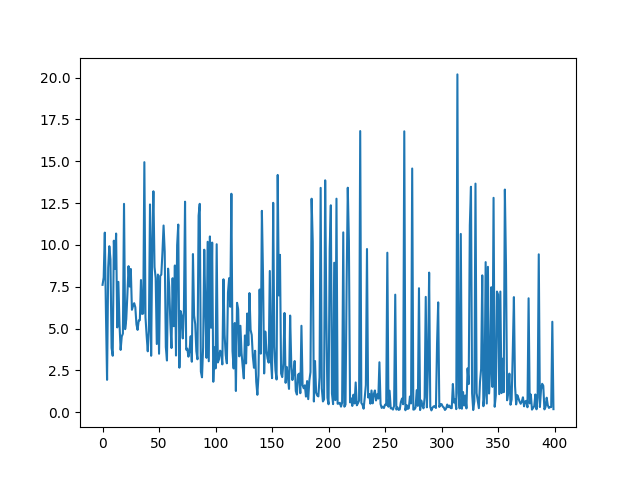

In [25]:
Image(filename='losses.png') 

# Play a game against your alphazero agent !

In [26]:
# as first player
gameplay=Play(ConnectN(**game_setting), 
              player1=None, 
              player2=Policy_Player_MCTS)

In [27]:
# as second player
gameplay=Play(ConnectN(**game_setting), 
              player2=None, 
              player1=Policy_Player_MCTS)
